In [ ]:
from model_v2_w6ms3.My.Encoder_sober import *
from model_v2_w6ms3.My.train_v22_hard_fbmask import *
from torch.utils.data import Dataset, DataLoader
from model_v2_w6ms3.DataLoader import *

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
cfg = {
  "data": {
    "data_root": "../../Data",
    "stats_file": "stats.json",
    "crop_size": [
      352,
      1216
    ],
    "seq_len": 4,
    "center_frame_idx": 10,
    "split": "training",
    "image_folder": "image_2",
    "flow_type": "flow_occ",
    "disp_type": "disp_occ",
    "normalize": True,
    "return_pair_only": False
  },
  "model": {
    "pair_feat_ch": 64,
    "corr_radius": 4,
    "pair_embed_ch": 128,
    "predict_flow_init": True,
    "visual_in_ch": 3,
    "visual_base_ch": 32,
    "visual_out_ch": 64,
    "motion_in_ch": 128,
    "motion_hidden_ch": 128,
    "motion_out_ch": 64,
    "fusion_visual_ch": 64,
    "fusion_motion_ch": 64,
    "fusion_hidden_ch": 128,
    "fusion_out_ch": 128,
    "uno_use_valid_mask": True,
    "uno_hidden_channels": 64,
    "uno_lifting_channels": 128,
    "uno_projection_channels": 128,
    "uno_n_layers": 4,
    "uno_out_channels": [
      64,
      128,
      128,
      64
    ],
    "uno_n_modes": [
      [
        16,
        16
      ],
      [
        12,
        12
      ],
      [
        12,
        12
      ],
      [
        16,
        16
      ]
    ],
    "uno_scalings": [
      [
        1.0,
        1.0
      ],
      [
        0.5,
        0.5
      ],
      [
        2.0,
        2.0
      ],
      [
        1.0,
        1.0
      ]
    ],
    "decoder_in_ch": 128,
    "decoder_hidden_ch": 64,
    "decoder_upsample": 8,
    "decoder_use_prev_flow": True
  },
  "train": {
    "batch_size": 2,
    "num_epochs": 400,
    "lr": 0.0001,
    "weight_decay": 0.0001,
    "num_workers": 0,
    "shuffle": True,
    "pin_memory": True,
    "log_every_n_steps": 10,
    "seed": 42,
    "save_epoch_checkpoints": [
      50,
      100,
      150,
      200
    ]
  },
  "loss": {
    "lambda_temp": 0.03,
    "lambda_smooth": 0.01,
    "lambda_self": 0.1,
    "lambda_edge_weight": 1.0,
    "photo_lambda_l1": 0.15,
    "photo_lambda_ssim": 0.85,
    "photo_lambda_census": 0.3,
    "photo_census_patch": 7,
    "photo_multiframe_reduction": "mean",
    "photo_use_confidence": True,
    "photo_texture_floor": 0.05,
    "photo_robust_beta": 10.0,
    "photo_use_fb_consistency": True,
    "photo_bidirectional": True,
    "fb_alpha": 0.01,
    "fb_beta": 0.5,
    "fb_gamma": 2.0,
    "fb_conf_floor": 0.05,
    "lambda_acc_photo": 0.05,
    "lambda_acc_smooth": 0.0,
    "accum_max_skip": 2,
    "lambda_fb": 0.01,
    "fb_loss_robust_eps": 0.01,
    "photo_use_hard_fb_mask": True,
    "fb_mask_alpha1": 0.01,
    "fb_mask_alpha2": 0.5
  },
  "experiment": {
    "experiment_name": "v22_hard_fbmask",
    "save_dir": "checkpoints",
    "tensorboard_dir": "runs",
    "checkpoint_name": "fullpipeline_v22_latest.pth",
    "best_checkpoint_name": "fullpipeline_v22_best.pth",
    "config_dump_name": "config_v22_hard_fbmask.json"
  }
}

In [ ]:
def read_rgb_img(path):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32) / 255.0


def read_kitti_flow(path):
    flow_png = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if flow_png is None:
        raise FileNotFoundError(f"Flow not found: {path}")

    flow_png = flow_png.astype(np.float32)

    valid = flow_png[:, :, 0] > 0
    u = (flow_png[:, :, 2] - 32768.0) / 64.0
    v = (flow_png[:, :, 1] - 32768.0) / 64.0

    flow = np.stack([u, v], axis=-1).astype(np.float32)
    valid = valid.astype(np.float32)

    return flow, valid


def read_kitti_disp(path):
    disp_png = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if disp_png is None:
        raise FileNotFoundError(f"Disparity not found: {path}")

    disp_png = disp_png.astype(np.float32)
    disp = disp_png / 256.0
    valid = (disp_png > 0).astype(np.float32)

    return disp, valid


def read_obj_map(path):
    obj = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if obj is None:
        raise FileNotFoundError(f"Object map not found: {path}")

    return obj.astype(np.int32)


def center_crop(arr, crop_size):
    crop_h, crop_w = crop_size
    h, w = arr.shape[:2]

    if crop_h > h or crop_w > w:
        raise RuntimeError(f"Crop size {crop_size} larger than image size {h}x{w}")

    top = (h - crop_h) // 2
    left = (w - crop_w) // 2

    if arr.ndim == 3:
        return arr[top:top + crop_h, left:left + crop_w, :]
    elif arr.ndim == 2:
        return arr[top:top + crop_h, left:left + crop_w]
    else:
        raise RuntimeError(f"Unexpected arr.ndim={arr.ndim}")


def obj_map_to_boxes(obj_map, min_area=20, return_masks=False):
    """
    obj_map:
        [H,W], integer instance id map

    Returns detection target:
        boxes:  [N,4], xyxy
        labels: [N], all ones
        obj_ids:[N]
        optional masks: [N,H,W]
    """

    boxes = []
    labels = []
    obj_ids = []
    masks = []

    unique_ids = np.unique(obj_map)

    for obj_id in unique_ids:
        if obj_id == 0:
            continue

        mask = obj_map == obj_id
        ys, xs = np.where(mask)

        if len(xs) == 0:
            continue

        x1 = xs.min()
        x2 = xs.max()
        y1 = ys.min()
        y2 = ys.max()

        w = x2 - x1 + 1
        h = y2 - y1 + 1
        area = w * h

        if area < min_area:
            continue

        boxes.append([x1, y1, x2, y2])
        labels.append(1)
        obj_ids.append(int(obj_id))

        if return_masks:
            masks.append(mask.astype(np.uint8))

    target = {
        "boxes": torch.tensor(boxes, dtype=torch.float32),
        "labels": torch.tensor(labels, dtype=torch.long),
        "obj_ids": torch.tensor(obj_ids, dtype=torch.long),
    }

    if return_masks:
        if len(masks) > 0:
            target["masks"] = torch.from_numpy(np.stack(masks, axis=0)).to(torch.uint8)
        else:
            H, W = obj_map.shape
            target["masks"] = torch.zeros((0, H, W), dtype=torch.uint8)

    return target


def detection_collate_fn(batch):
    out = {}

    for k in batch[0].keys():
        if k == "label":
            out[k] = [b[k] for b in batch]
        elif isinstance(batch[0][k], torch.Tensor):
            out[k] = torch.stack([b[k] for b in batch], dim=0)
        else:
            out[k] = [b[k] for b in batch]

    return out


class TempFlowDataset_ObjMap(Dataset):
    """
    KITTI Flow / Scene Flow dataset with aligned obj_map labels.

    Uses:
        Additional_frames/training/image_2/000000_08.png ...
        Flow/training/flow_occ/000000_10.png
        Flow/training/obj_map/000000_10.png

    Output:
        imgs:          [T,3,H,W]
        flow:          [2,H,W]
        valid:         [H,W]
        label:         dict with boxes/labels/obj_ids
        seq_id:        str, e.g. "000000"
        flow_frame:    long, usually 10
        frame_indices: [T]
    """

    def __init__(
        self,
        root,
        split="training",
        image_folder="image_2",
        flow_type="flow_occ",
        disp_type="disp_occ",
        seq_len=5,
        crop_size=(352, 1216),
        normalize=True,
        stats_in=None,
        return_pair_only=False,
        min_obj_area=20,
        return_masks=False,
        require_obj_map=True,
    ):
        super().__init__()

        self.root = Path(root)
        self.split = split
        self.image_folder = image_folder
        self.flow_type = flow_type
        self.disp_type = disp_type
        self.seq_len = seq_len
        self.crop_size = crop_size
        self.normalize = normalize
        self.stats_in = stats_in
        self.return_pair_only = return_pair_only
        self.min_obj_area = min_obj_area
        self.return_masks = return_masks
        self.require_obj_map = require_obj_map

        self.additional_frames_dir = (
            self.root / "Additional_frames" / split / image_folder
        )

        self.flow_dir = self.root / "Flow" / split / flow_type
        self.obj_map_dir = self.root / "Flow" / split / "obj_map"

        self.disp0_dir = self.root / "Flow" / split / f"{disp_type}_0"
        self.disp1_dir = self.root / "Flow" / split / f"{disp_type}_1"

        if not self.additional_frames_dir.exists():
            raise FileNotFoundError(f"Missing image folder: {self.additional_frames_dir}")

        if not self.flow_dir.exists():
            raise FileNotFoundError(f"Missing flow folder: {self.flow_dir}")

        if self.require_obj_map and not self.obj_map_dir.exists():
            raise FileNotFoundError(f"Missing obj_map folder: {self.obj_map_dir}")

        if not self.disp0_dir.exists():
            raise FileNotFoundError(f"Missing disparity folder: {self.disp0_dir}")

        if not self.disp1_dir.exists():
            raise FileNotFoundError(f"Missing disparity folder: {self.disp1_dir}")

        self.samples = self._build_samples()

        if len(self.samples) == 0:
            raise RuntimeError("No valid samples found.")

        self.stats = self._load_stats()

    def _build_samples(self):
        flow_files = sorted(self.flow_dir.glob("*.png"))
        samples = []

        half = self.seq_len // 2

        for flow_path in flow_files:
            stem = flow_path.stem          # e.g. 000030_10
            seq_id, frame_str = stem.split("_")
            flow_frame = int(frame_str)

            if self.return_pair_only:
                frame_indices = [flow_frame, flow_frame + 1]
            else:
                start = flow_frame - half + 1
                frame_indices = list(range(start, start + self.seq_len))

            img_paths = []

            valid_sample = True
            for t in frame_indices:
                img_path = self.additional_frames_dir / f"{seq_id}_{t:02d}.png"

                if not img_path.exists():
                    valid_sample = False
                    break

                img_paths.append(str(img_path))

            if not valid_sample:
                continue

            obj_map_path = self.obj_map_dir / f"{seq_id}_{flow_frame:02d}.png"

            if self.require_obj_map and not obj_map_path.exists():
                continue

            disp_name = f"{seq_id}_{flow_frame:02d}.png"
            disp0_path = self.disp0_dir / disp_name
            disp1_path = self.disp1_dir / disp_name

            if not disp0_path.exists() or not disp1_path.exists():
                continue

            samples.append({
                "seq_id": seq_id,
                "flow_frame": flow_frame,
                "frame_indices": frame_indices,
                "img_paths": img_paths,
                "flow_path": str(flow_path),
                "obj_map_path": str(obj_map_path),
                "disp0_path": str(disp0_path),
                "disp1_path": str(disp1_path),
            })

        return samples

    def _load_stats(self):
        if self.stats_in is not None and os.path.exists(self.stats_in):
            with open(self.stats_in, "r") as f:
                return json.load(f)

        stats = self.compute_stats()

        if self.stats_in is not None:
            dirname = os.path.dirname(self.stats_in)
            if dirname != "":
                os.makedirs(dirname, exist_ok=True)

            with open(self.stats_in, "w") as f:
                json.dump(stats, f, indent=2)

        return stats

    def compute_stats(self):
        channel_sum = np.zeros(3, dtype=np.float64)
        channel_sq_sum = np.zeros(3, dtype=np.float64)
        pixel_count = 0

        seen = set()

        for sample in self.samples:
            for img_path in sample["img_paths"]:
                if img_path in seen:
                    continue

                seen.add(img_path)

                img = read_rgb_img(img_path)

                if self.crop_size is not None:
                    img = center_crop(img, self.crop_size)

                h, w, _ = img.shape
                flat = img.reshape(-1, 3)

                channel_sum += flat.sum(axis=0)
                channel_sq_sum += (flat ** 2).sum(axis=0)
                pixel_count += h * w

        mean = channel_sum / pixel_count
        var = channel_sq_sum / pixel_count - mean ** 2
        std = np.sqrt(np.maximum(var, 1e-8))

        return {
            "mean": mean.tolist(),
            "std": std.tolist(),
            "num_unique_frames": len(seen),
            "num_samples": len(self.samples),
        }

    def _normalize_img(self, img):
        mean = np.array(self.stats["mean"], dtype=np.float32)
        std = np.array(self.stats["std"], dtype=np.float32)
        return (img - mean) / std

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        imgs = []

        for img_path in sample["img_paths"]:
            img = read_rgb_img(img_path)

            if self.crop_size is not None:
                img = center_crop(img, self.crop_size)

            if self.normalize:
                img = self._normalize_img(img)

            img = torch.from_numpy(img).permute(2, 0, 1).contiguous()
            imgs.append(img)

        imgs = torch.stack(imgs, dim=0)

        flow, valid = read_kitti_flow(sample["flow_path"])

        if self.crop_size is not None:
            flow = center_crop(flow, self.crop_size)
            valid = center_crop(valid, self.crop_size)

        flow = torch.from_numpy(flow).permute(2, 0, 1).contiguous()
        valid = torch.from_numpy(valid).contiguous()

        obj_map = read_obj_map(sample["obj_map_path"])

        if self.crop_size is not None:
            obj_map = center_crop(obj_map, self.crop_size)

        target = obj_map_to_boxes(
            obj_map,
            min_area=self.min_obj_area,
            return_masks=self.return_masks,
        )

        disp0, disp_valid0 = read_kitti_disp(sample["disp0_path"])
        disp1, disp_valid1 = read_kitti_disp(sample["disp1_path"])

        if self.crop_size is not None:
            disp0 = center_crop(disp0, self.crop_size)
            disp1 = center_crop(disp1, self.crop_size)
            disp_valid0 = center_crop(disp_valid0, self.crop_size)
            disp_valid1 = center_crop(disp_valid1, self.crop_size)

        disp0 = torch.from_numpy(disp0).unsqueeze(0).contiguous()
        disp1 = torch.from_numpy(disp1).unsqueeze(0).contiguous()
        disp_valid0 = torch.from_numpy(disp_valid0).unsqueeze(0).contiguous()
        disp_valid1 = torch.from_numpy(disp_valid1).unsqueeze(0).contiguous()

        disp = torch.stack([disp0, disp1], dim=0)
        disp_valid = torch.stack([disp_valid0, disp_valid1], dim=0)

        output = {
            "imgs": imgs,
            "flow": flow,
            "valid": valid,
            "label": target,
            "obj_map": torch.from_numpy(obj_map).long(),
            "disp": disp,
            "disp_valid": disp_valid,
            "seq_id": sample["seq_id"],
            "flow_frame": torch.tensor(sample["flow_frame"], dtype=torch.long),
            "frame_indices": torch.tensor(sample["frame_indices"], dtype=torch.long),
        }

        if imgs.shape[0] >= 2:
            gt_src = sample["flow_frame"]
            indices = sample["frame_indices"]

            if gt_src in indices and (gt_src + 1) in indices:
                src_pos = indices.index(gt_src)
                tgt_pos = indices.index(gt_src + 1)

                output["img_src"] = imgs[src_pos]
                output["img_tgt"] = imgs[tgt_pos]
                output["src_idx_in_seq"] = torch.tensor(src_pos, dtype=torch.long)
                output["tgt_idx_in_seq"] = torch.tensor(tgt_pos, dtype=torch.long)

        return output

In [ ]:
set_seed(cfg["train"]["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = TempFlowDataset_ObjMap(
        root=cfg["data"]["data_root"],
        split=cfg["data"]["split"],
        image_folder=cfg["data"]["image_folder"],
        flow_type=cfg["data"]["flow_type"],
        disp_type=cfg["data"]["disp_type"],
        seq_len=cfg["data"]["seq_len"],
        #center_frame_idx=cfg["data"]["center_frame_idx"],
        crop_size=tuple(cfg["data"]["crop_size"]),
        normalize=cfg["data"]["normalize"],
        stats_in=cfg["data"]["stats_file"],
        return_pair_only=cfg["data"]["return_pair_only"],
    )

train_loader = DataLoader(
        dataset,
        batch_size=cfg["train"]["batch_size"],
        shuffle=cfg["train"]["shuffle"],
        num_workers=cfg["train"]["num_workers"],
        pin_memory=cfg["train"]["pin_memory"],
        collate_fn=detection_collate_fn
    )

modules = build_modules(cfg, device)
optimizer = torch.optim.AdamW(
        [p for module in modules.values() for p in module.parameters()],
        lr=1e-4,
        weight_decay=1e-4
    )


In [ ]:
def forward_pipeline(modules, imgs, valid, uno_use_valid_mask=True):
        pair_encoder = modules['pair_encoder'].to(device)
        pair_out = pair_encoder(imgs)
        #pair_out = modules["pair_encoder"](imgs).to(device)
        pair_feats = pair_out["pair_feats"].to(device)
        flow_inits = pair_out["flow_inits"].to(device)
        corrs = pair_out["corrs"].to(device)

        if flow_inits is None:
            raise RuntimeError("v19 UNO integration requires predict_flow_init=True in the pair encoder.")

        visual_feats = modules["visual_branch"](imgs)
        motion_feats = modules["motion_branch"](pair_feats)
        fused_seq = modules["fusion"](visual_feats, motion_feats)

        valid_ds = None
        if uno_use_valid_mask:
            valid_ds = downsample_valid_mask(valid, fused_seq.shape[-2:])

        uno_in = build_uno_input_2d(fused_seq, flow_inits, valid_mask=valid_ds)
        uno_feat = modules["uno"](uno_in)

        b, tm, _, h, w = fused_seq.shape
        latent_delta = modules["latent_head"](uno_feat, b, tm, h, w)
        refined_seq = fused_seq + latent_delta

        flows, flow_residuals = modules["decoder"](refined_seq, flow_inits=flow_inits)

        return {
            "flows": flows,
            "flow_inits": flow_inits,
            "pair_feats": pair_feats,
            "corrs": corrs,
            "fused_seq": fused_seq,
            "latent_delta": latent_delta,
            "refined_seq": refined_seq,
            "flow_residuals": flow_residuals,
        }

In [ ]:
def load_checkpoint(ckpt_path, modules, device, optimizer=None, strict=True):
    ckpt = torch.load(ckpt_path, map_location=device)

    # ---- load module weights ----
    for name, module in modules.items():
        key = f"{name}_state_dict"
        if key in ckpt:
            module.load_state_dict(ckpt[key], strict=strict)
        else:
            print(f"[Warning] Missing key: {key}")

        module.to(device)

    # ---- load optimizer (optional) ----
    if optimizer is not None and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    # ---- metadata ----
    epoch = ckpt.get("epoch", None)
    stats = ckpt.get("stats", None)
    config = ckpt.get("config", None)

    print(f"Loaded checkpoint complete from: {ckpt_path} (epoch={epoch})")

    return {
        "epoch": epoch,
        "stats": stats,
        "config": config,
    }

In [ ]:
meta = load_checkpoint(
    ckpt_path="../../model_v2_w6ms3/My/fullpipeline_v22_best.pth",
    modules=modules,
    device=device,
    optimizer=optimizer,   # optional
)
for m in modules.values():
    m.to(device)
    print(m)

In [ ]:
batch = next(iter(train_loader))
out = forward_pipeline(modules, batch["imgs"].to(device), batch["valid"].to(device), uno_use_valid_mask=True)
print(out['flows'].shape)

In [ ]:
import model_v2_w6ms3.Detector as Detector
import importlib
importlib.reload(Detector)
from model_v2_w6ms3.Detector import *

In [ ]:
ID_TO_CLASS_NAME = {
    1: "object",
}

detector = FlowObjectDetector(
    num_classes=2,
    in_ch=3,          # u, v, magnitude
    pretrained_backbone=True,
)


optimizer = torch.optim.AdamW(
    detector.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

trainer = FlowDetectionTrainer(
    flow_modules=modules,
    detector=detector,
    train_loader=train_loader,
    val_loader=None,
    optimizer=optimizer,
    device=device,
    flow_index=1,
    use_mag=True,
    use_valid=False,
    freeze_flow=True,
)



In [ ]:
trainer.fit(epochs=10)

In [ ]:
def load_detector_ckpt(ckpt_path, device="cuda"):
    detector = FlowObjectDetector(
        num_classes=2,
        in_ch=3,                  # u, v, magnitude
        pretrained_backbone=False # weights will come from ckpt
    ).to(device)

    ckpt = torch.load(ckpt_path, map_location=device)

    detector.load_state_dict(ckpt["detector_state_dict"])
    detector.eval()

    print(f"Loaded checkpoint: {ckpt_path}")
    print(f"Epoch: {ckpt.get('epoch', 'unknown')}")

    return detector, ckpt

ckpt_path = "../../model_v2_w6ms3/ckpts/detector_epoch_050.pt"
detector, ckpt = load_detector_ckpt(ckpt_path, device=device)

for name, param in detector.named_parameters():
     print(name, param.shape, param.requires_grad)

In [ ]:
@torch.no_grad()
def inference_one_batch(
    batch,
    flow_modules,
    detector,
    device,
    flow_index=0,
    use_mag=True,
    use_valid=False,
    score_thresh=0.3,
):
    detector.eval()
    for m in flow_modules.values():
        m.eval()

    imgs = batch["imgs"].to(device)

    valid = batch.get("valid", None)
    if valid is not None:
        valid = valid.to(device)

    # 1. Predict optical flow
    flow_out = forward_pipeline(
        modules=modules,
        imgs=imgs,
        valid=valid,
    )

    pred_flows = flow_out["flows"]  # [B, Tm, 2, H, W]

    # 2. Build detector input
    flow_x = build_flow_detector_input(
        pred_flows=pred_flows,
        valid=valid,
        flow_index=flow_index,
        use_mag=use_mag,
        use_valid=use_valid,
    )  # [B, C, H, W]

    det_images = [x for x in flow_x]

    # 3. Faster R-CNN inference
    det_out = detector(det_images)  # list[dict]

    # 4. Filter boxes by confidence
    detections = []

    for det in det_out:
        keep = det["scores"] >= score_thresh

        detections.append({
            "boxes": det["boxes"][keep].detach().cpu(),
            "labels": det["labels"][keep].detach().cpu(),
            "scores": det["scores"][keep].detach().cpu(),
        })

    return {
        "pred_flows": pred_flows.detach().cpu(),
        "detector_input": flow_x.detach().cpu(),
        "detections": detections,
    }

In [ ]:
batch = next(iter(train_loader))

result = inference_one_batch(
    batch=batch,
    flow_modules=modules,
    detector=detector,
    device=device,
    flow_index=0,
    use_mag=True,
    use_valid=False,
    score_thresh=0.3,
)

print(result["pred_flows"].shape)

for i, det in enumerate(result["detections"]):
    print(f"sample {i}")
    print(det["boxes"])
    print(det["labels"])
    print(det["scores"])
    
det = result["detections"][0]

boxes = det["boxes"]      # [N, 4], xyxy
labels = det["labels"]    # [N]
scores = det["scores"]    # [N]

In [21]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2


ID_TO_CLASS_NAME = {
    1: 'Object'
}

def flow_to_rgb(flow):
    """
    flow: [2,H,W] torch tensor or numpy array
    returns: [H,W,3] RGB uint8
    """
    if isinstance(flow, torch.Tensor):
        flow = flow.detach().cpu().numpy()

    u = flow[0]
    v = flow[1]

    mag, ang = cv2.cartToPolar(u, v, angleInDegrees=True)

    hsv = np.zeros((flow.shape[1], flow.shape[2], 3), dtype=np.uint8)
    hsv[..., 0] = ang / 2
    hsv[..., 1] = 255
    hsv[..., 2] = np.clip(mag / (np.percentile(mag, 99) + 1e-6) * 255, 0, 255)

    rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    return rgb


def draw_boxes(ax, boxes, labels=None, scores=None, color="lime", linewidth=2, prefix=""):
    """
    boxes: [N,4], xyxy
    labels: [N]
    scores: [N]
    """
    if isinstance(boxes, torch.Tensor):
        boxes = boxes.detach().cpu()

    if labels is not None and isinstance(labels, torch.Tensor):
        labels = labels.detach().cpu()

    if scores is not None and isinstance(scores, torch.Tensor):
        scores = scores.detach().cpu()

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.tolist()
        w = x2 - x1
        h = y2 - y1

        rect = patches.Rectangle(
            (x1, y1),
            w,
            h,
            linewidth=linewidth,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)

        text = prefix

        if labels is not None:
            cls_id = int(labels[i])
            cls_name = ID_TO_CLASS_NAME.get(cls_id, str(cls_id))
            text += cls_name

        if scores is not None:
            text += f" {float(scores[i]):.2f}"

        if text.strip():
            ax.text(
                x1,
                max(y1 - 3, 0),
                text,
                color=color,
                fontsize=8,
                bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
            )


def visualize_gt_and_pred(
    result,
    batch,
    sample_idx=1,
    flow_index=0,
    score_thresh=0.3,
):
    """
    Top:    GT
    Bottom: Predictions
    """

    pred_flow = result["pred_flows"][sample_idx, flow_index]  # [2,H,W]
    flow_rgb = flow_to_rgb(pred_flow)

    gt = batch["label"][sample_idx]
    pred = result["detections"][sample_idx]

    # ---------------------------
    # Create 2-row figure
    # ---------------------------
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # ===========================
    # TOP: GT
    # ===========================
    ax_gt = axes[0]
    ax_gt.imshow(flow_rgb)
    ax_gt.axis("off")

    draw_boxes(
        ax_gt,
        boxes=gt["boxes"],
        labels=gt["labels"],
        scores=None,
        color="lime",
        linewidth=2,
        prefix="GT ",
    )

    ax_gt.set_title("Ground Truth (Green)")

    # ===========================
    # BOTTOM: Predictions
    # ===========================
    ax_pred = axes[1]
    ax_pred.imshow(flow_rgb)
    ax_pred.axis("off")

    if pred["boxes"].numel() > 0:
        scores = pred["scores"]
    
        # confidence filtering
        keep = scores >= score_thresh
    
        if keep.any():
            draw_boxes(
                ax_pred,
                boxes=pred["boxes"][keep],
                labels=pred["labels"][keep] if "labels" in pred else None,
                scores=scores[keep],
                color="red",
                linewidth=2,
                prefix="Pred ",
            )

    ax_pred.set_title(f"Predictions (Red) | score_thresh={score_thresh}")

    plt.tight_layout()
    plt.savefig('1.png')
    plt.show()


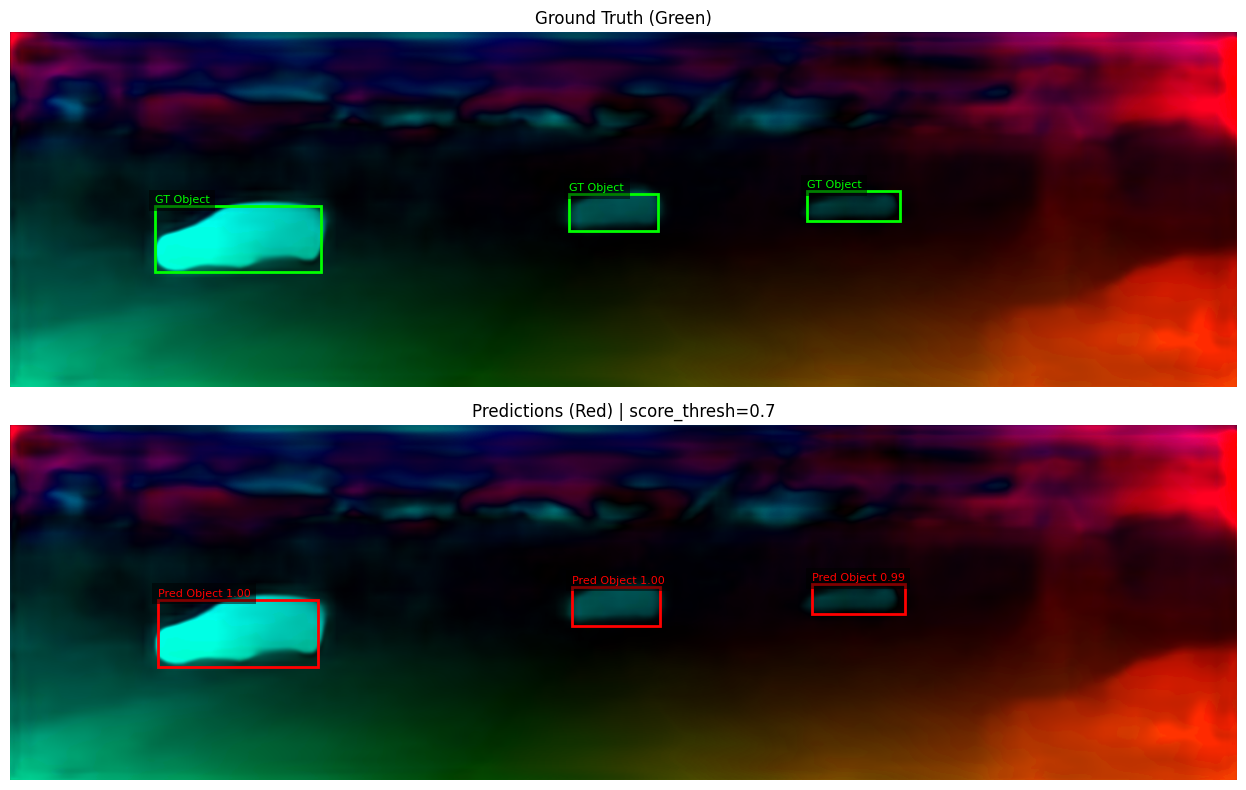

<Figure size 640x480 with 0 Axes>

In [22]:
batch = next(iter(train_loader))
result = inference_one_batch(
    batch=batch,
    flow_modules=modules,
    detector=detector,
    device=device,
    flow_index=1,
    use_mag=True,
    use_valid=False,
    score_thresh=0.5,
)

visualize_gt_and_pred(
    result=result,
    batch=batch,
    sample_idx=0,
    flow_index=1,
    score_thresh=0.7,
)